In [1]:
import scanpy as sc
import os
import os, sys
import scipy
import pandas as pd
import scanpy as sc
# import dask
import squidpy as sq
import matplotlib.pyplot as plt
import numpy as np

import pickle
import seaborn as sns
import gseapy as gp



adata=sc.read_h5ad('/nfs/team361/ls34/inflow/adata_mm_spatial_finalv.h5ad')

In [2]:
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(14,14))


In [2]:
# #adata.uns['log1p']['base'] = None
CATEGORY = 'spatial_niche'
ADATA = adata

sc.tl.rank_genes_groups(adata, CATEGORY, method='t-test', key_added="de_leiden");
df2 = pd.DataFrame(adata.uns['de_leiden']['names'])
for i,x in enumerate(df2.columns):
     print(i,":",x)
#T_GENES = list(df2["T"].values[:200])
#MELANOMA_GENES = list(df2["Melanoma"].values[:400])


0 : Epidermis
1 : Mac_hub
2 : Melanoma1
3 : Melanoma2
4 : Perivascular
5 : Plasma cell hub
6 : Stroma
7 : T_hub


/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


In [3]:
result = adata.uns['de_leiden']
groups = result['names'].dtype.names
groups = ["Melanoma2", "Melanoma1"]
marker_genes = pd.DataFrame({group: result['names'][group] for group in groups})
#marker_genes

In [4]:
print(marker_genes.head())

  Melanoma2 Melanoma1
0     HOXB7    ATP1A1
1    S100A1     MLANA
2       VGF      AKT2
3       MME      CDK2
4      PAEP    S100A1


In [5]:
gsea_results = []

for cluster in marker_genes.columns:
    gene_list = marker_genes[cluster].tolist()
    enr = gp.enrichr(gene_list=gene_list[:100],
                     gene_sets='GO_Biological_Process_2023',   
                     outdir=None,  
                     cutoff=0.05  # Cutoff for statistical significance
                    )
    enr.results['Cluster'] = cluster
    gsea_results.append(enr.results)

gsea_df = pd.concat(gsea_results)

In [6]:
color_palettes = {"Melanoma1":'#000000',
                 "Melanoma2":  '#A9A9A9', #BROWN = 5C4033
                  
                 }

/tmp/ipykernel_25572/3753508098.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_gsea_df = gsea_df.groupby('Cluster').apply(lambda x: x.nlargest(N_PATHWAYS, 'Combined Score')).reset_index(drop=True)


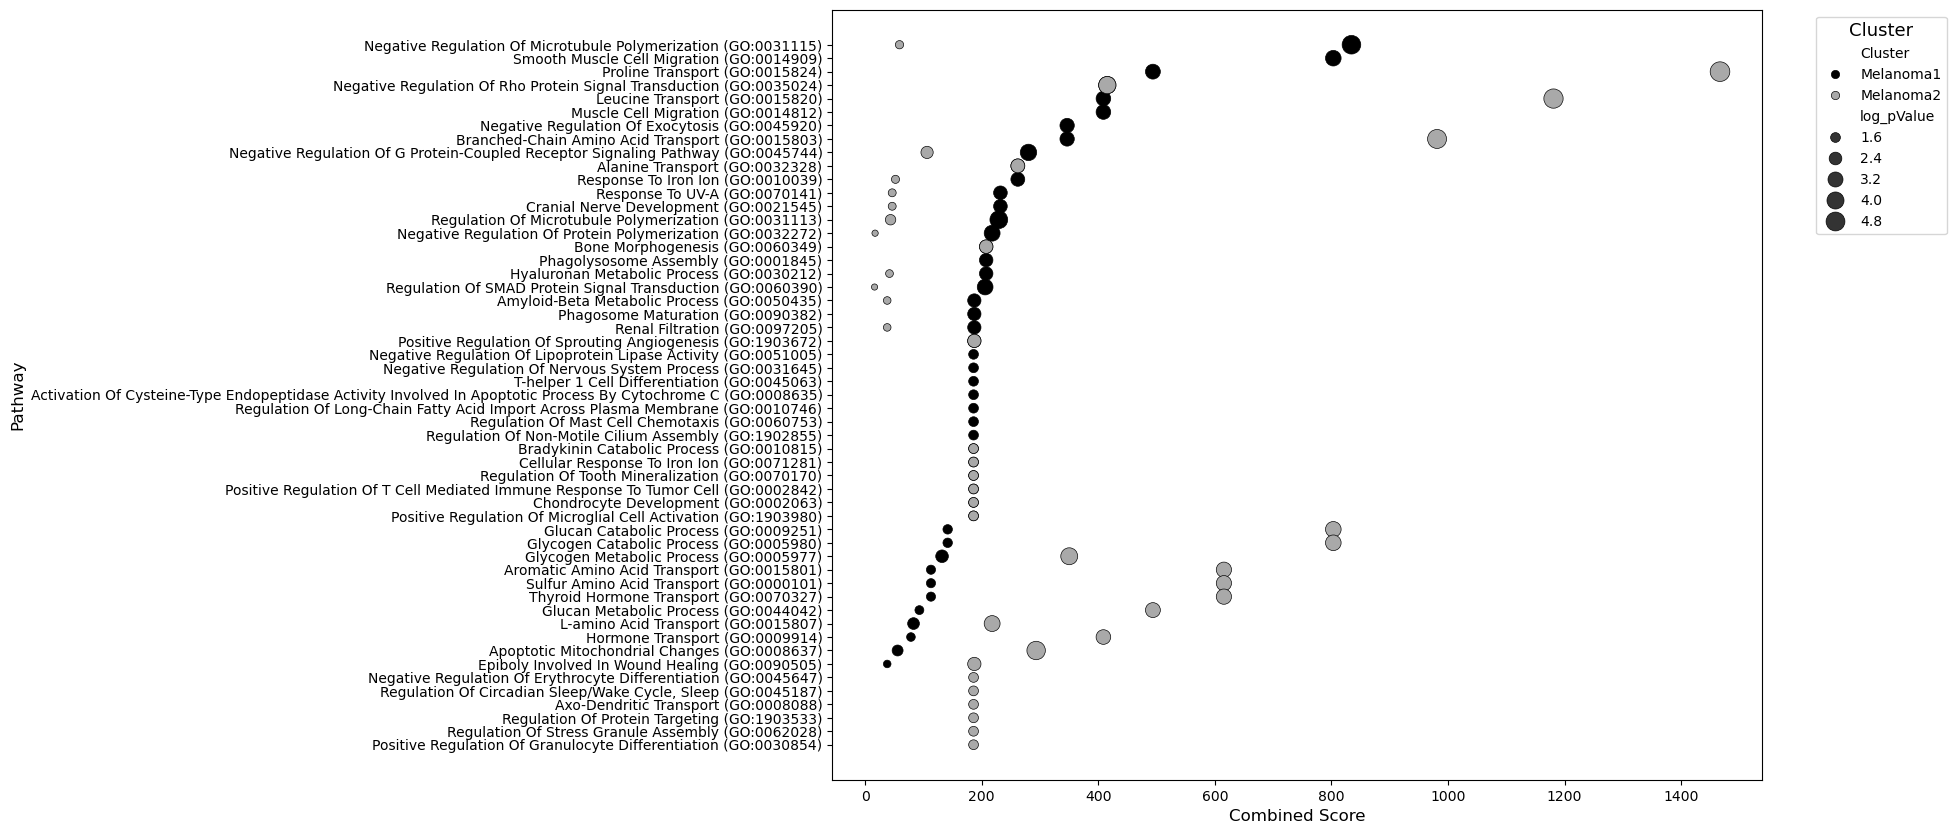

In [7]:
N_PATHWAYS = 30
top_gsea_df = gsea_df.groupby('Cluster').apply(lambda x: x.nlargest(N_PATHWAYS, 'Combined Score')).reset_index(drop=True)
top_pathways = top_gsea_df['Term'].unique()
filtered_gsea_df = gsea_df[gsea_df['Term'].isin(top_pathways)].copy()
filtered_gsea_df['log_pValue'] = -np.log10(filtered_gsea_df['P-value'])
filtered_gsea_df = filtered_gsea_df.sort_values(by=['Cluster', 'Combined Score'], ascending=[True, False])

plt.figure(figsize=(12, 10))
ax = sns.scatterplot(
    x="Combined Score", y="Term", hue="Cluster", size="log_pValue",
    data=filtered_gsea_df, palette=color_palettes, sizes=(20, 200), edgecolor="black"
)

plt.title('', fontsize=16)
plt.xlabel('Combined Score', fontsize=12)
plt.ylabel('Pathway', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize='13')


plt.show()

/tmp/ipykernel_25572/4050601271.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_gsea_df = gsea_df.groupby('Cluster').apply(lambda x: x.nlargest(N_PATHWAYS, 'Combined Score')).reset_index(drop=True)


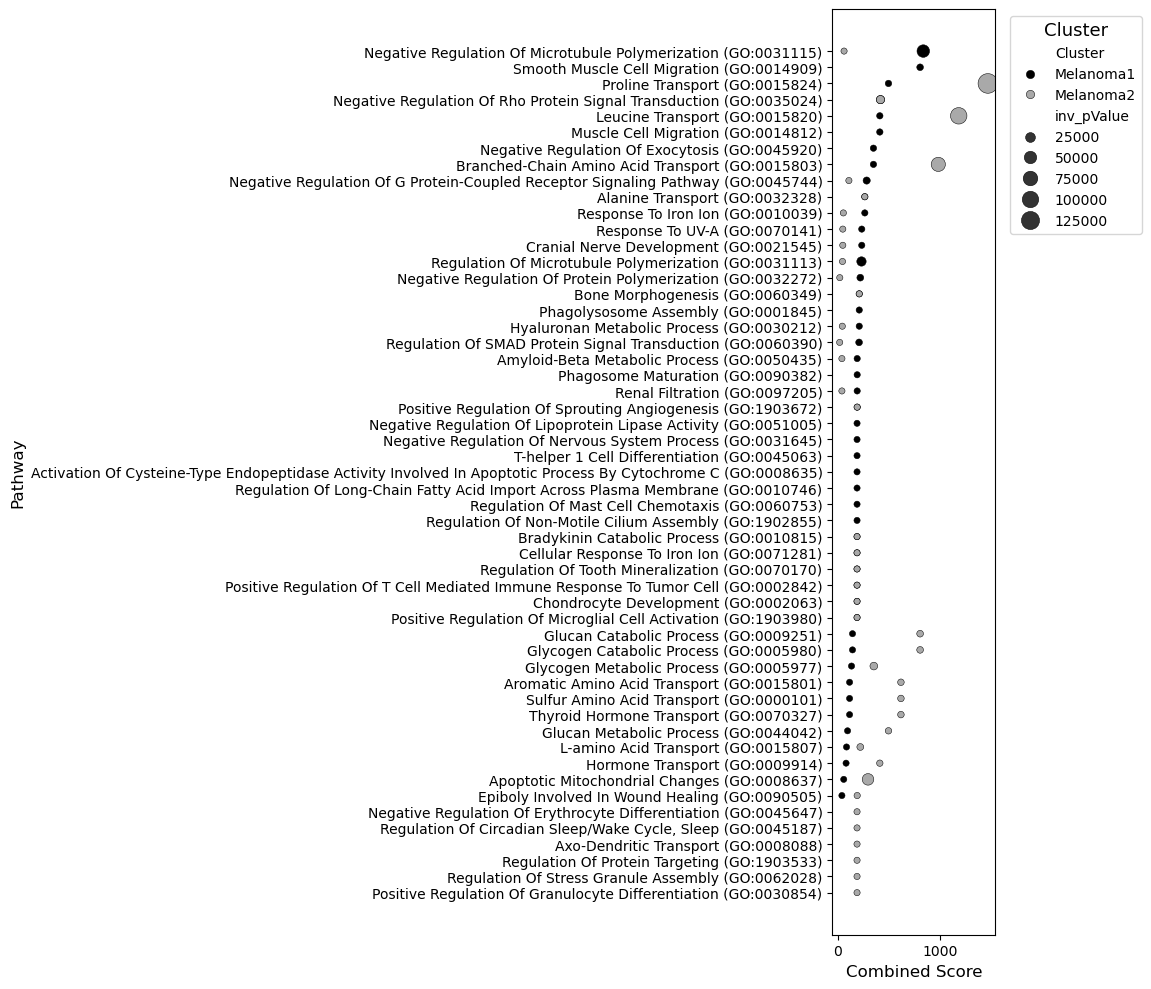

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

N_PATHWAYS = 30
top_gsea_df = gsea_df.groupby('Cluster').apply(lambda x: x.nlargest(N_PATHWAYS, 'Combined Score')).reset_index(drop=True)
top_pathways = top_gsea_df['Term'].unique()
filtered_gsea_df = gsea_df[gsea_df['Term'].isin(top_pathways)].copy()

filtered_gsea_df['pValue'] = filtered_gsea_df['P-value']
filtered_gsea_df['inv_pValue'] = 1 / filtered_gsea_df['P-value']

filtered_gsea_df = filtered_gsea_df.sort_values(by=['Cluster', 'Combined Score'], ascending=[True, False])

plt.figure(figsize=(12, 10))
ax = sns.scatterplot(
    x="Combined Score", y="Term", hue="Cluster", size="inv_pValue",
    data=filtered_gsea_df, palette=color_palettes, sizes=(20, 200), edgecolor="black"
)

plt.title('', fontsize=16)
plt.xlabel('Combined Score', fontsize=12)
plt.ylabel('Pathway', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize='13')

plt.tight_layout()
plt.savefig("figures/gsea_analysis.pdf", dpi=300, bbox_inches='tight')
plt.show()

# supp fig 6b

/tmp/ipykernel_25572/3997873119.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_gsea_df = gsea_df.groupby('Cluster').apply(lambda x: x.nlargest(N_PATHWAYS, 'Combined Score')).reset_index(drop=True)


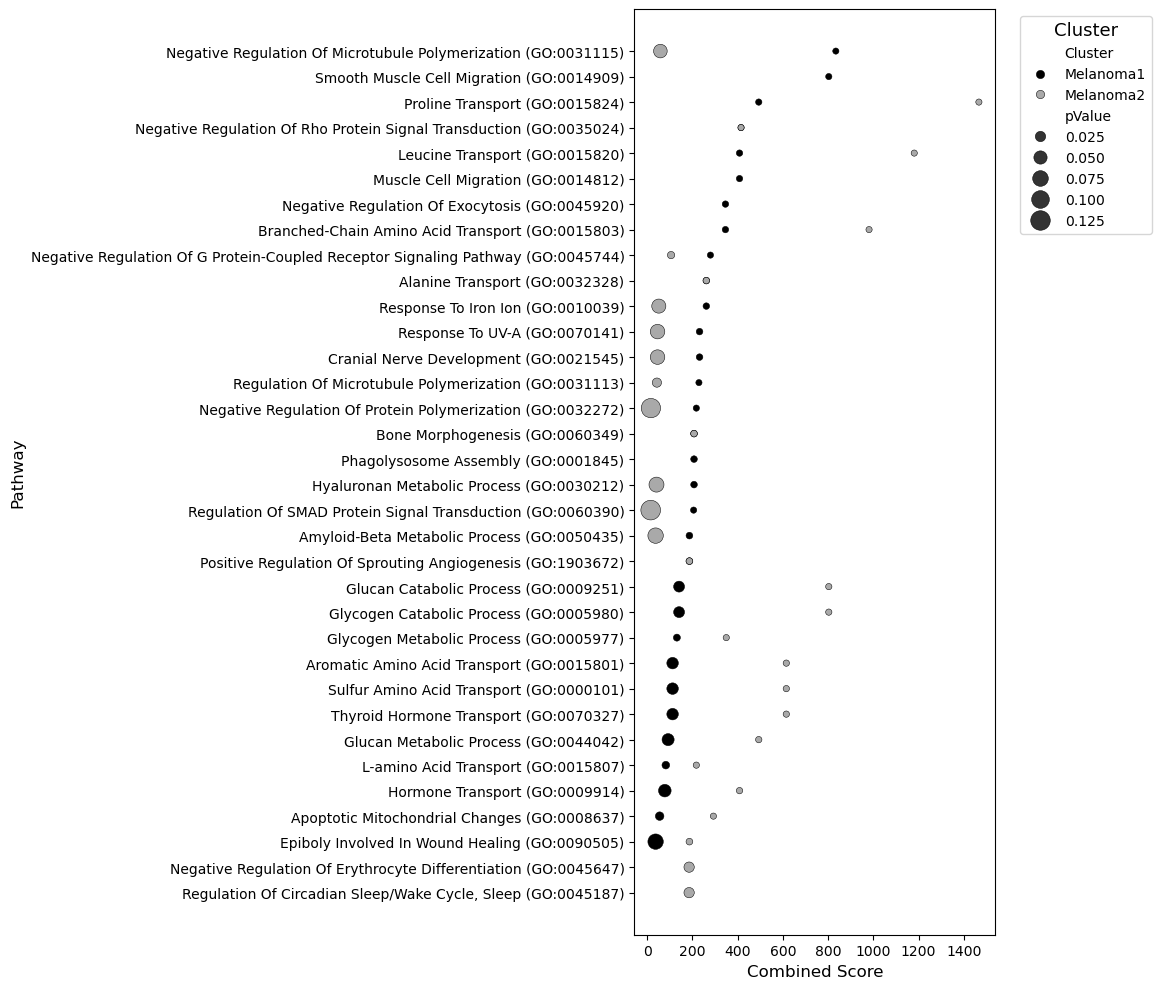

In [19]:
N_PATHWAYS = 20
top_gsea_df = gsea_df.groupby('Cluster').apply(lambda x: x.nlargest(N_PATHWAYS, 'Combined Score')).reset_index(drop=True)
top_pathways = top_gsea_df['Term'].unique()
filtered_gsea_df = gsea_df[gsea_df['Term'].isin(top_pathways)].copy()

filtered_gsea_df['pValue'] = filtered_gsea_df['P-value']

filtered_gsea_df = filtered_gsea_df.sort_values(by=['Cluster', 'Combined Score'], ascending=[True, False])

plt.figure(figsize=(12, 10))
ax = sns.scatterplot(
    x="Combined Score", y="Term", hue="Cluster", size="pValue",
    data=filtered_gsea_df, palette=color_palettes, sizes=(20, 200), edgecolor="black"
)

plt.title('', fontsize=16)
plt.xlabel('Combined Score', fontsize=12)
plt.ylabel('Pathway', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize='13')

plt.tight_layout()
plt.savefig("figures/gsea_analysis.pdf", dpi=300, bbox_inches='tight')
plt.show()